In [105]:
library(dplyr)
library(ggplot2)
library(patchwork)
library(data.table)

source("/mnt/lareaulab/reliscu/code/ggplot_theme.R")
source("/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/code/top_corr_module_fxns.R")
source("/mnt/lareaulab/reliscu/projects/NSF_GRFP/analyses/code/module_projection_fxns.R")

theme_set(default_theme())

In [2]:
mod_def <- "PosBC"

In [3]:
expr <- fread("/mnt/lareaulab/reliscu/projects/NSF_GRFP/data/scRNA-seq/yao_2021/MOp/yao_2021_MOp_STAR_gene_counts.csv", data.table=FALSE)
sampleinfo <- fread("/mnt/lareaulab/reliscu/projects/NSF_GRFP/data/scRNA-seq/yao_2021/MOp/yao_2021_MOp_STAR_sampleinfo.csv", data.table=FALSE)

In [58]:
ctype_tally <- table(sampleinfo$subclass_label)
ctypes_to_keep <- names(ctype_tally)[ctype_tally > 5]
cells_to_keep <- which(sampleinfo$subclass_label %in% ctypes_to_keep)
expr <- expr[, c(1, cells_to_keep + 1)]
sampleinfo <- sampleinfo[cells_to_keep,]

In [59]:
all.equal(colnames(expr)[-1], sampleinfo$Cell_ID)

[1] TRUE

In [5]:
# From enrichments results:

In [6]:
network_dir <- "GTEx_cortex_TPM_All_598_outliers_removed_ComBat_SMGEBTCH_corrected_mergeParam0.95_subsetCutoff0.26_Modules"
network_files <- list.files(file.path(network_dir, "Bicor-None_signum0.8_minSize10_merge_ME_0.95_22277"), full.names=TRUE)
kME_path <- network_files[grep("kME_table", network_files)]
mod <- "black"
mod_genes <- get_mod_genes(kME_path, mod, mod_def)

In [7]:
# For each module of interest:

In [107]:
ctype_index_list <- get_module_ctype_index(expr, mod_genes, sampleinfo$subclass_label)
ctype_expr_index <- ctype_index_list[[1]]
ctype_index_se <- ctype_index_list[[2]] 

In [108]:
df <- data.frame(
    Cell_type=names(ctype_expr_index),
    Index=ctype_expr_index,
    SE=ctype_index_se,
    No.cells=as.numeric(table(sampleinfo$subclass_label))
)

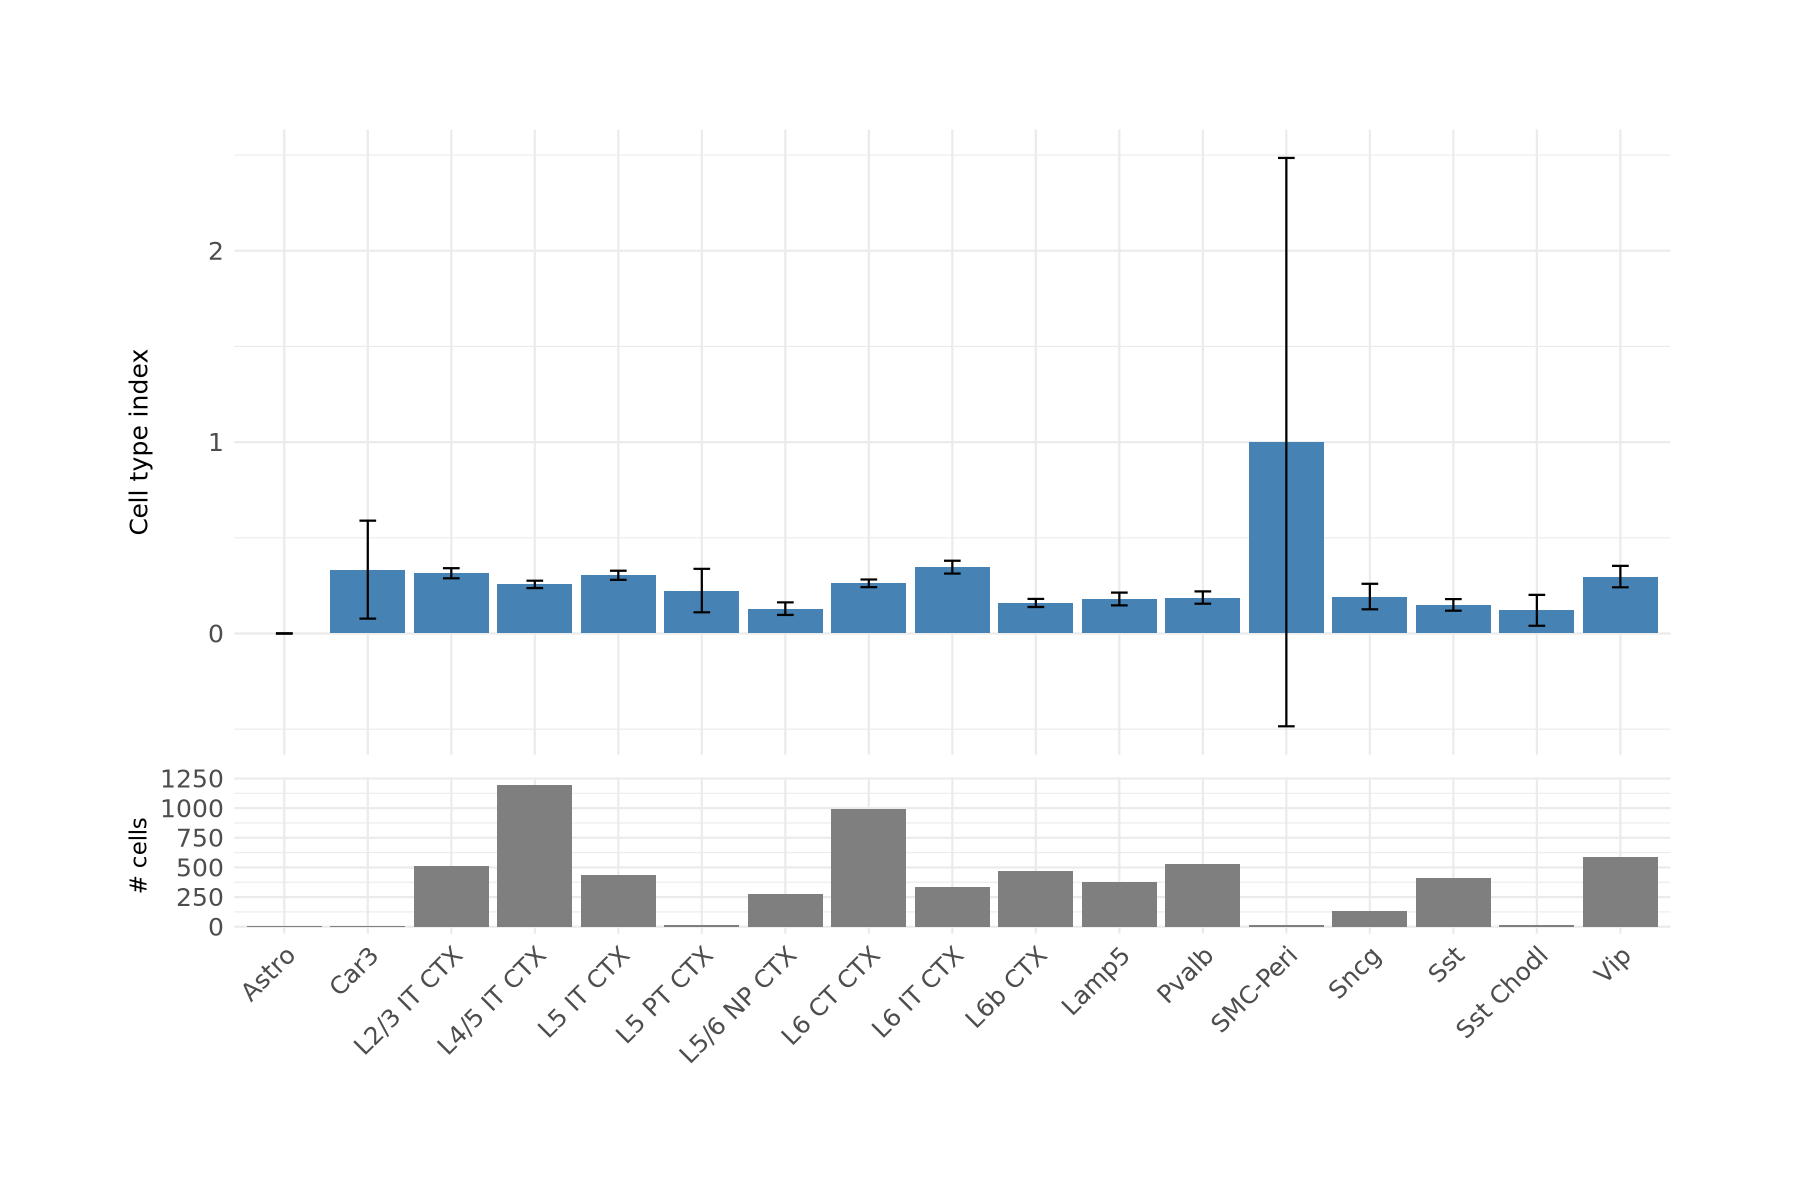

In [111]:
index_plot <- ggplot(data=df, aes(x=Cell_type, y=Index)) +
    geom_bar(stat="identity", fill="steelblue") +
    geom_errorbar(aes(ymin=Index-2*SE, ymax=Index+2*SE), width=0.2) +
    labs(y="Cell type index") +
    theme_minimal() +
    theme(
        axis.title.x=element_blank(),
        axis.text.x=element_blank(),  # Remove labels from top
        axis.text.y=element_text(size=12),
        axis.title.y=element_text(size=12)
    )

n_cells_plot <- ggplot(data=df, aes(x=Cell_type, y=No.cells)) +
    geom_bar(stat="identity", fill="gray50") +
    labs(y="# cells") +
    theme_minimal() +
    theme(
        axis.title.x=element_blank(),
        axis.text.x=element_text(size=12, angle=45, hjust=1),
        axis.text.y=element_text(size=12)
    ) 
    # scale_y_continuous(trans="log2")


# Stack them
index_plot / n_cells_plot + plot_layout(heights=c(4, 1))
